In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import scanpy as sc
import scvi
import seaborn as sns



/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

## Load Data

In [2]:
# Save dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [3]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna.h5ad')

h5_rna_union = sc.read_h5ad(h5_rna_union_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
h5_rna_union, h5_rna_union.shape

(AnnData object with n_obs × n_vars = 2381 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',
 (2381, 36601))

In [5]:
sc.pp.filter_genes(h5_rna_union, min_counts=3)
h5_rna_union.raw = h5_rna_union # keep full dimension safe
h5_rna_union.layers['counts'] = h5_rna_union.X
sc.pp.highly_variable_genes(
h5_rna_union    ,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)


# Normalization for visualization
h5_rna_union.layers['log1p_counts'] = np.log1p(h5_rna_union.X)
h5_rna_union.layers['cpm'] = sc.pp.normalize_total(h5_rna_union, target_sum=1e4, inplace=False)['X']
h5_rna_union.layers['log1p_cpm'] = np.log1p(h5_rna_union.layers['cpm'])

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [6]:
SCVI_LATENT_KEY = "RNA_scVI_unionBC"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI_unionBC"


vae_model_folder=os.path.join(entropy_dir, "_unioncells_RNA_scvi_model")
vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna_union)
h5_rna_union.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.3)


# clustering using scVI latent representation via Leiden
atac_resolution = 0.5
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.5)
sc.tl.leiden(h5_rna_union, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)

INFO     File /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_unioncells_RNA_scvi_model/model.pt      
         already downloaded                                                                                        


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

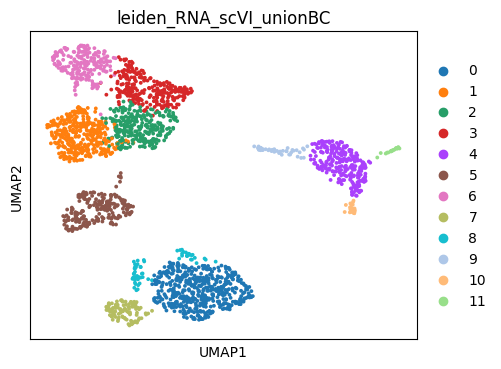

In [7]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['leiden_RNA_scVI_unionBC'], wspace=0.2, size=30, ncols=3)

In [8]:
col_list = ['total_fragments', 'atac_pass_CR', 'atac_pass_entropy',
       'atac_pass_archr_TSS', '_2set_identified_by_atac_SC',
       '_2set_identified_by_atac_ST', 'rna_barcodes', 'rna_pass_CR', 'Entropy', 'DNA_debris']
for col in col_list:
    h5_rna_union.obs[col] = h5_rna_union.obs['atac_barcodes'].map(union_cell_info[col])

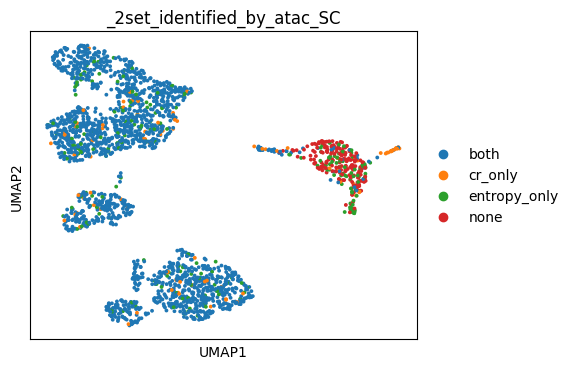

In [9]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['_2set_identified_by_atac_SC'], wspace=0.2, size=30, ncols=3)

# Now only subset BCs for comparing SADE/entropy vs CellRanger and analyze ATAC signals

In [12]:
h5_rna_SC = h5_rna_union[h5_rna_union.obs['_2set_identified_by_atac_SC'] != 'none'].copy()

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


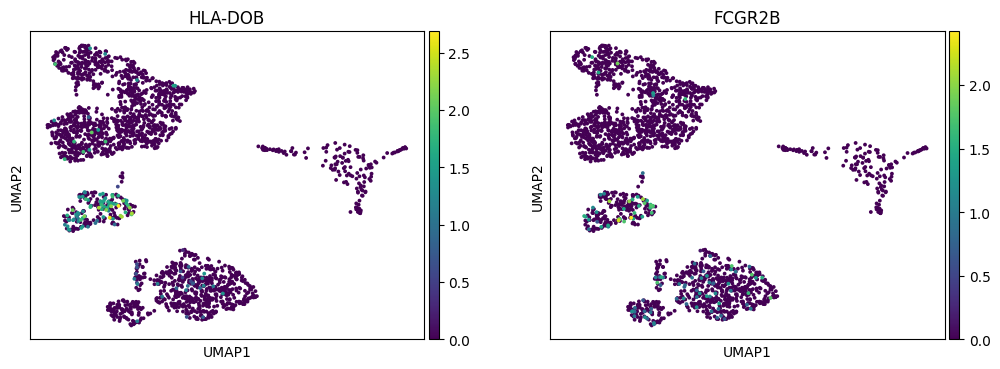

In [56]:
genes= ['PDGFRA', 'HLA-DOB', 'DMAP1', 'GPBAR1']
genes = ['HLA-DOB', 'FCGR2B']
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_SC, color=genes, wspace=0.2, size=30, ncols=3, layer='log1p_cpm')

In [13]:
h5_rna_SC.obs.head(2)

,rna_barcodes,atac_barcodes,total_RNA_UMI,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,MT%,_scvi_batch,_scvi_labels,leiden_RNA_scVI_unionBC,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_pass_CR,Entropy,DNA_debris
AAACAGCCAGGCTACT-1,AAACAGCCAGGCTACT,ACAGCGGGTTTGTAGC,3931.0,8.276903,1772,519.0,13.202747,0,0,1,3390,True,True,True,both,both,True,0.130478,NO
AAACATGCAAGGATTA-1,AAACATGCAAGGATTA,CATTTAGGTAACAGCA,3566.0,8.179481,1689,401.0,11.245092,0,0,3,11169,True,True,True,both,both,True,0.197080,NO


Text(0, 0.5, 'Total Fragments')

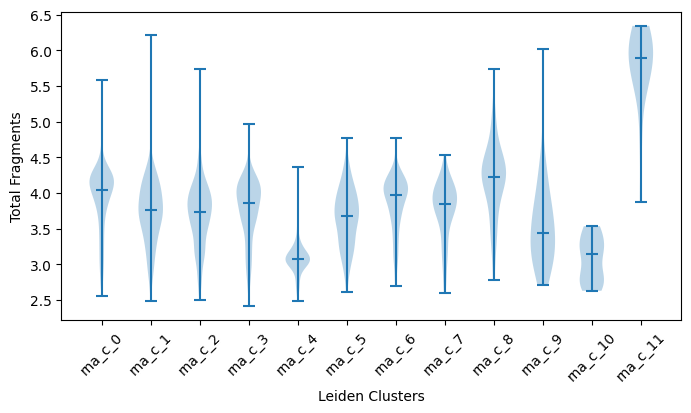

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

x_positions = h5_rna_union.obs['leiden_RNA_scVI_unionBC'].cat.codes.unique()
atac_read_depth = [h5_rna_union.obs['total_fragments'].apply(lambda x: np.log10(x + 1)).loc[
    (h5_rna_union.obs['leiden_RNA_scVI_unionBC'].cat.codes == cluster) 
    ] for cluster in x_positions]
ax.violinplot(atac_read_depth, positions=x_positions, showmeans=False, showmedians=True)
ax.set_xticks(x_positions)
ax.set_xticklabels(['rna_c_' + str(i) for i in x_positions], rotation=45)
ax.set_xlabel('Leiden Clusters')
ax.set_ylabel('Total Fragments')

Text(0, 0.5, 'Entropy (log10)')

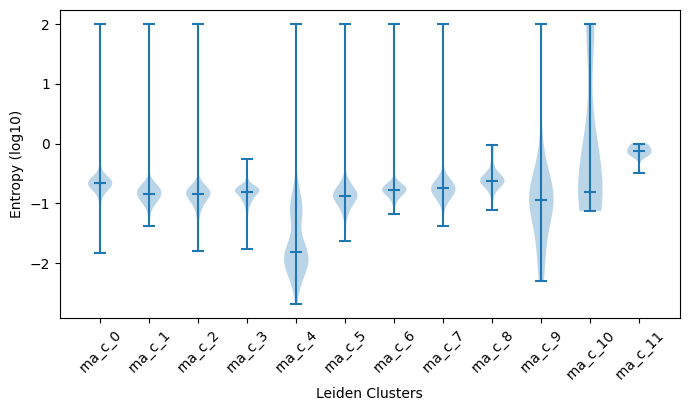

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

x_positions = h5_rna_union.obs['leiden_RNA_scVI_unionBC'].cat.codes.unique()
atac_read_depth = [h5_rna_union.obs['Entropy'].fillna(100).apply(lambda x: np.log10(x)).loc[
    (h5_rna_union.obs['leiden_RNA_scVI_unionBC'].cat.codes == cluster) 
    ] for cluster in x_positions]
ax.violinplot(atac_read_depth, positions=x_positions, showmeans=False, showmedians=True)
ax.set_xticks(x_positions)
ax.set_xticklabels(['rna_c_' + str(i) for i in x_positions], rotation=45)
ax.set_xlabel('Leiden Clusters')
ax.set_ylabel('Entropy (log10)')

Text(0, 0.5, 'Entropy (log10)')

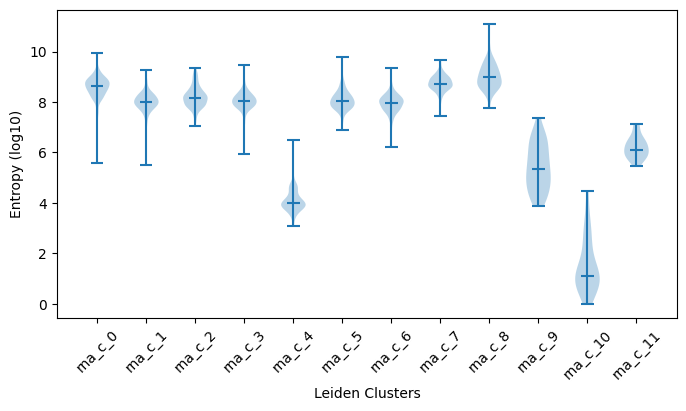

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

x_positions = h5_rna_union.obs['leiden_RNA_scVI_unionBC'].cat.codes.unique()
atac_read_depth = [h5_rna_union.obs['total_RNA_UMI_log'].loc[
    (h5_rna_union.obs['leiden_RNA_scVI_unionBC'].cat.codes == cluster) 
    ] for cluster in x_positions]
ax.violinplot(atac_read_depth, positions=x_positions, showmeans=False, showmedians=True)
ax.set_xticks(x_positions)
ax.set_xticklabels(['rna_c_' + str(i) for i in x_positions], rotation=45)
ax.set_xlabel('Leiden Clusters')
ax.set_ylabel('Entropy (log10)')